# **WAP to implement breast cancer and print & plot regression and prediction value**
### date : 18/08/2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
import mglearn

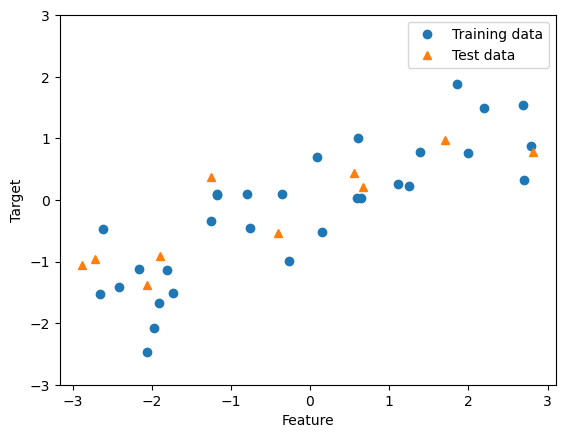

In [13]:
# Generate dataset
x, y = mglearn.datasets.make_wave(n_samples=40)

# Split the dataset into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

# Plot training and test data
plt.plot(x_train, y_train, 'o', label="Training data")
plt.plot(x_test, y_test, '^', label="Test data")
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()

Test set predictions for 1 neighbors:
[-0.3409073   0.03527881  1.87664889 -2.47196233 -1.52730805 -1.67303415
  0.03497884  0.86893293  0.09398858 -1.52730805]
Test set R^2 for 1 neighbors: 0.35
Test set predictions for 3 neighbors:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]
Test set R^2 for 3 neighbors: 0.83
Test set predictions for 7 neighbors:
[-0.45154299  0.24645302  0.98933747 -1.63125367 -1.53884951 -1.63125367
  0.24645302  1.09165292 -0.13966928 -1.53884951]
Test set R^2 for 7 neighbors: 0.68
Test set predictions for 9 neighbors:
[-0.76885025  0.16870118  0.81020743 -1.49113268 -1.49113268 -1.35931037
  0.16870118  0.90283566 -0.13712298 -1.49113268]
Test set R^2 for 9 neighbors: 0.65


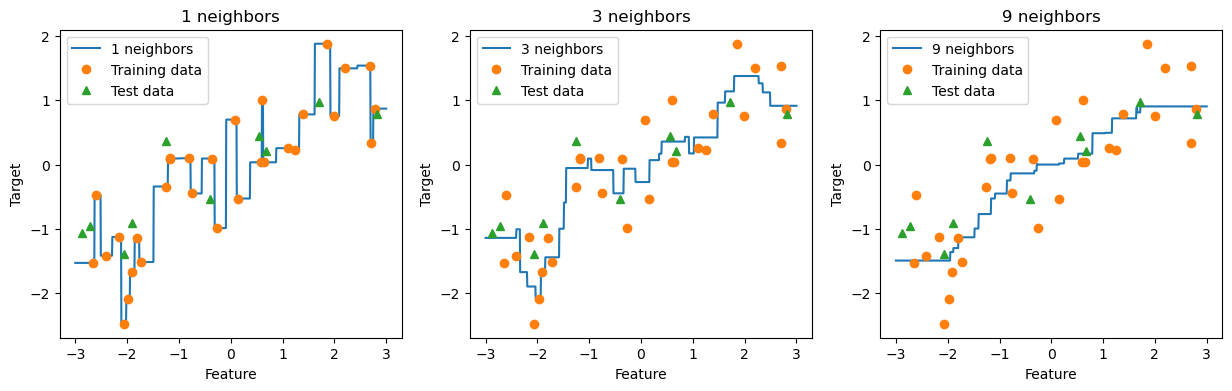

In [14]:
# Multiple plots for different neighbors
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

line = np.linspace(-3, 3, 1000).reshape(-1, 1)#[1000,1]

for n_neighbors, ax in zip([1, 3, 9], axes):
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(x_train, y_train)
    ax.plot(line, reg.predict(line), label=f"{n_neighbors} neighbors")
    ax.plot(x_train, y_train, 'o', label="Training data")
    ax.plot(x_test, y_test, '^', label="Test data")
    ax.set_title(f"{n_neighbors} neighbors")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
    ax.legend()

# Print predictions and R^2 score for each model
for n_neighbors in [1, 3,7, 9]:
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(x_train, y_train)

    print(f"Test set predictions for {n_neighbors} neighbors:\n{reg.predict(x_test)}")
    print(f"Test set R^2 for {n_neighbors} neighbors: {reg.score(x_test, y_test):.2f}")

plt.show()

# **2nd Code**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [5]:
# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target   # X = features (30), y = target (0 = malignant, 1 = benign)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Try different neighbors
for n_neighbors in [1, 3, 9]:
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    
    y_pred = reg.predict(X_test)
    
    print(f"\n===== {n_neighbors} Neighbors =====")
    print("First 10 predictions:", np.round(y_pred[:10], 3))
    print("First 10 actual:", y_test[:10])
    print("R^2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))


===== 1 Neighbors =====
First 10 predictions: [1. 0. 0. 1. 1. 0. 0. 0. 1. 1.]
First 10 actual: [1 0 0 1 1 0 0 0 1 1]
R^2 Score: 0.7235449735449735
MSE: 0.06432748538011696

===== 3 Neighbors =====
First 10 predictions: [0.333 0.    0.    1.    1.    0.    0.    0.    1.    1.   ]
First 10 actual: [1 0 0 1 1 0 0 0 1 1]
R^2 Score: 0.8519988242210464
MSE: 0.03443794671864848

===== 9 Neighbors =====
First 10 predictions: [0.778 0.    0.    1.    1.    0.    0.    0.111 1.    0.889]
First 10 actual: [1 0 0 1 1 0 0 0 1 1]
R^2 Score: 0.8842674243908812
MSE: 0.026929463576637065


In [6]:
axes

array([<Axes: title={'center': '1 neighbors'}, xlabel='Feature', ylabel='Target'>,
       <Axes: title={'center': '3 neighbors'}, xlabel='Feature', ylabel='Target'>,
       <Axes: title={'center': '9 neighbors'}, xlabel='Feature', ylabel='Target'>],
      dtype=object)

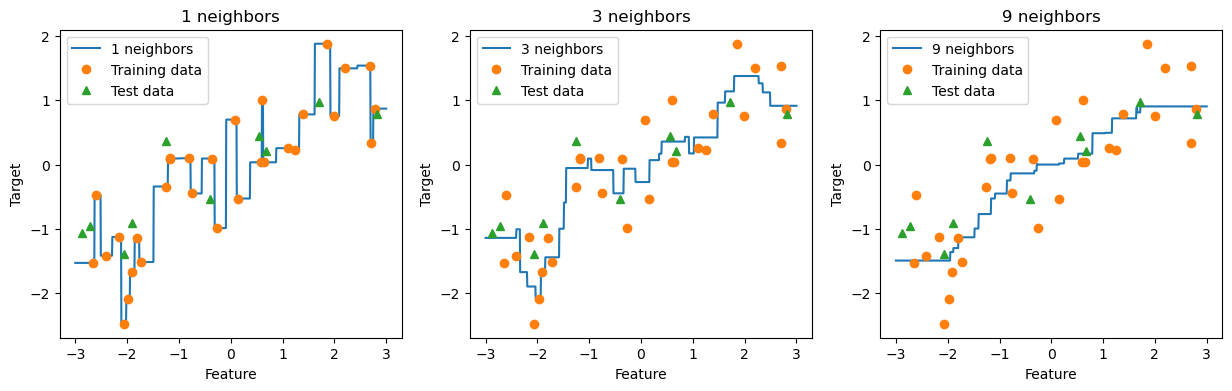

In [8]:
fig

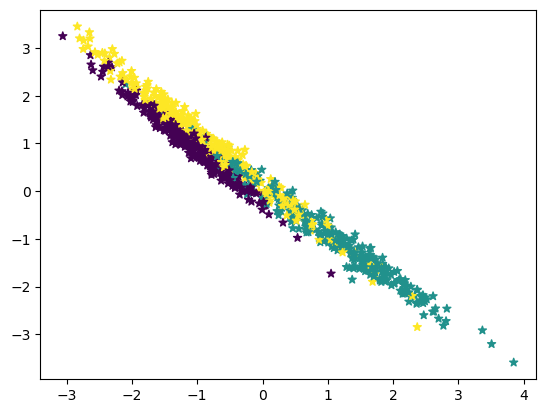

Actual Value: 0
Predicted Value: 0
Accuracy: 92.42424242424242 %
F1 Score: 92.48386445955693 %


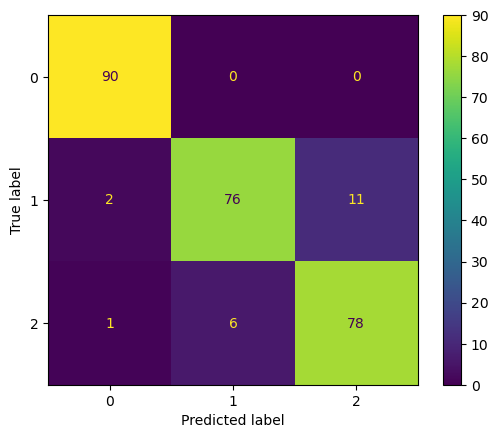

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Create a synthetic dataset
X, y = make_classification(n_features=6, n_classes=3, n_samples=800, n_informative=3, random_state=1, n_clusters_per_class=1)

# Plot the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, marker="*")
plt.show()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

# Create and train the Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Make predictions on the test set
predicted = model.predict(X_test[6].reshape(1, -1))


# Print actual and predicted values
print("Actual Value:", y_test[6])
print("Predicted Value:", predicted[0])

# Predict for all the test data
y_pred = model.predict(X_test)

# Calculate accuracy and F1 score
accuracy = accuracy_score(y_pred, y_test)
f1 = f1_score(y_pred, y_test, average='weighted')

# Print accuracy and F1 score
print("Accuracy:", accuracy * 100, "%")
print("F1 Score:", f1 * 100, "%")

# Display confusion matrix
labels = [0, 1, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.show()
